In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re


directory = './1_200G_4376.5109_4377.4913_fac_lat0_long0_r0_v4000_i90/'

#band
#directory = './1_4376.5109_4377.4913_band_lat45_90_v4000'




# print the header of the first file to get the simulation parameters
first_csv = next(Path('.').glob(f'{directory}/transit_lc*.csv'), None)
if first_csv:
    with open(first_csv, 'r') as f:
        header = f.readline()
        print("Simulation Parameters:")
        print(header.strip())
        print(' ')
else:
    print("No .csv files found to read the header from.")

lightcurves = {}
# read all the csv files in the directory and store the light curves in a dictionary based on wavelength
for csv_file in Path(directory).glob('transit_lc*.csv'):
    # Extract the wavelength from the filename using regex
    match = re.search(r'transit_lc_(\d+\.?\d*)\.csv', csv_file.name)
    if match:
        wavelength = float(match.group(1))
        data = np.loadtxt(csv_file, delimiter=',', skiprows=1)
        lightcurves[wavelength] = data
    else:
        print(f"Could not extract wavelength from filename: {csv_file.name}")

Simulation Parameters:
# disk_fill_phase_0=0.0, res2d=30, res3d=4, mode=faconly, fac_r=[0], fac_long=[0], fac_lat=[0], fac_band=False, fac_band_low=[-2.5], fac_band_high=[2.5], ld=power2, v_eq=4000, inc=90, rp=0.1808, b=-0.04, N=49, a=2, T=20, phi=0.8, hd_ld_file=test_phot.txt, fac_ld_file=test_fac_200G.txt
 


In [2]:
print(lightcurves.keys())

dict_keys([4376.9661, 4377.2287, 4377.3162, 4376.8085, 4377.3863, 4376.896, 4376.5284, 4376.931, 4377.3512, 4377.1061, 4376.5109, 4377.0361, 4377.0011, 4376.6509, 4376.861, 4377.2462, 4377.4388, 4376.826, 4376.7385, 4376.6684, 4377.4038, 4376.791, 4377.2987, 4377.0186, 4376.5459, 4377.2637, 4376.8785, 4376.721, 4377.0711, 4376.7034, 4376.9135, 4377.4213, 4377.1762, 4376.5634, 4376.8435, 4377.2812, 4377.0886, 4376.6334, 4377.1411, 4376.9836, 4377.3337, 4377.3688, 4377.1236, 4377.1937, 4376.7735, 4376.9485, 4377.1586, 4377.4563, 4377.4738, 4376.5809, 4376.6859, 4376.5984, 4377.0536, 4377.4913, 4376.6159, 4376.756, 4377.2112])


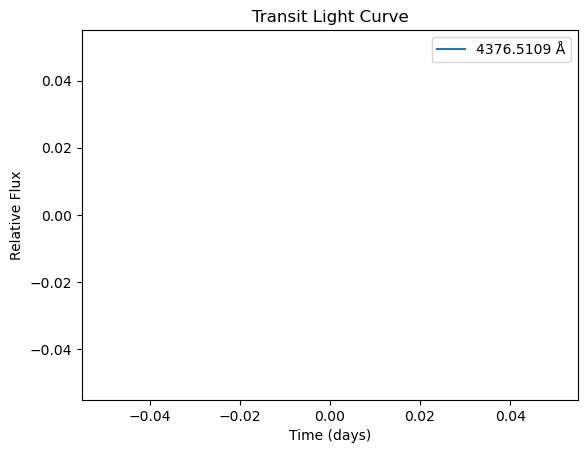

In [3]:
plt.plot(np.arange(len(lightcurves[4376.5109])), lightcurves[4376.5109], label='4376.5109 Å')
plt.xlabel('Time (days)')
plt.ylabel('Relative Flux')
plt.title('Transit Light Curve')
plt.legend()
plt.show()

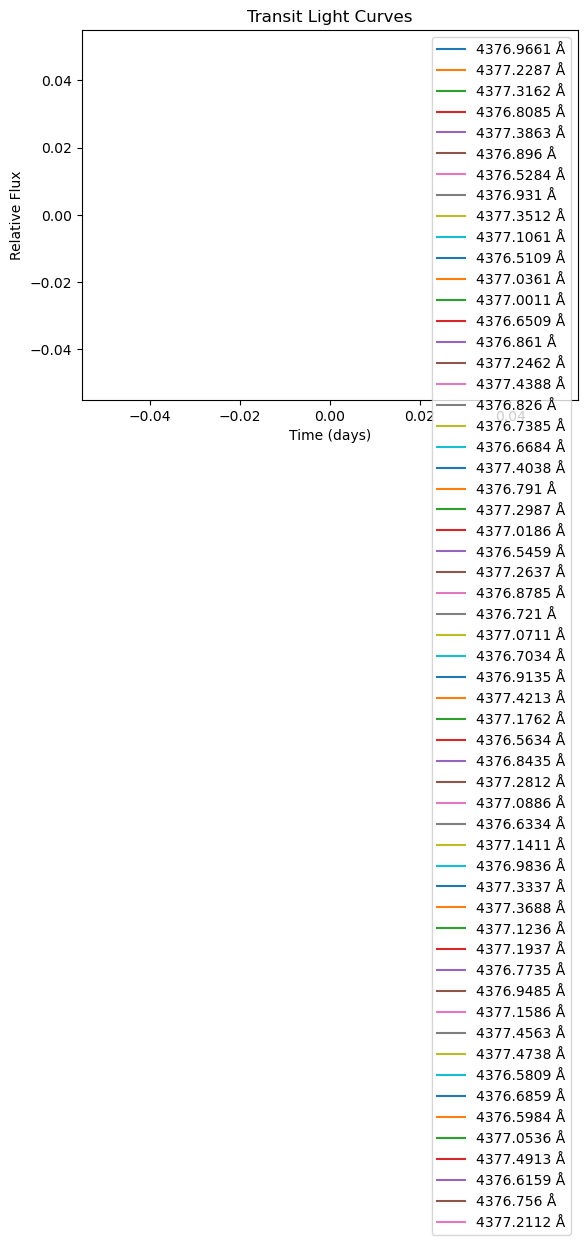

In [4]:
#plot all the lightcurves on the same plot
for wavelength, data in lightcurves.items():
    plt.plot(np.arange(len(data)), data, label=f'{wavelength} Å')
plt.xlabel('Time (days)')
plt.ylabel('Relative Flux')
plt.title('Transit Light Curves')
plt.legend()
plt.show()